# Audio Classification with RNN / LSTM (PyTorch)

This Colab notebook walks you through a **complete sequence-modeling pipeline for audio classification** using PyTorch:
- Create a **custom `Dataset`** class for audio + features (log-mel spectrograms)
- Define **RNN/LSTM** model classes (configurable)
- Implement **training & validation** loops with **accuracy** and **cross-entropy loss**
- **Tune hyperparameters** (simple grid) if desired
- **Plot** training/validation curves
- Build a **test** evaluator with **Confusion Matrix** and **Classification Report**


**The label for this lab is the speaker. In essence the goal is to predict who is speaking.**

## Setup


In [1]:
!pip -q install torchaudio librosa soundfile scikit-learn


In [2]:
import os, math, random, time, json, itertools, shutil
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torchaudio.transforms as T
import librosa
import soundfile as sf
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch.optim as optim
from tqdm import tqdm
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

## Define the arguments needed to instantiate the MyCustomDataset class


We begin by loading the `label.csv` metadata file. This file contains the filename, label. The files are stored in the folder recording.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


We will be using the log-mel spectrogram transformation of torchaudio

SAMPLE_RATE = 8000
NUM_SAMPLES = 8000

In [4]:
SAMPLE_RATE = 8000
NUM_SAMPLES = 8000
TARGET_MS = NUM_SAMPLES * 1000 // SAMPLE_RATE

ANNOTATIONS_FILE = '/content/drive/MyDrive/FSDD/label.csv'
AUDIO_DIR = '/content/drive/MyDrive/FSDD/recording'

In [5]:
import pandas as pd

df = pd.read_csv(ANNOTATIONS_FILE)

# Preview the first few rows
df.head()

,file_name,speaker,label
0,8_lucas_9.wav,lucas,8
1,0_theo_17.wav,theo,0
2,1_theo_13.wav,theo,1
3,1_george_12.wav,george,1
4,5_jackson_14.wav,jackson,5


BE CAREFUL THE LABEL IS SPEAKER....

In [6]:
annotation_df = pd.read_csv(ANNOTATIONS_FILE)  # has columns: filename, speaker
speakers = sorted(annotation_df.iloc[:, 1].unique())          # unique speaker names
num_classes = len(speakers)

speaker_to_id = {name: idx for idx, name in enumerate(speakers)}
annotation_df['speaker_id'] = annotation_df['speaker'].map(speaker_to_id)
annotation_df.head()

,file_name,speaker,label,speaker_id
0,8_lucas_9.wav,lucas,8,2
1,0_theo_17.wav,theo,0,4
2,1_theo_13.wav,theo,1,4
3,1_george_12.wav,george,1,0
4,5_jackson_14.wav,jackson,5,1


## Define Transforms (torchaudio)


We use torchaudio to define our transformation pipeline:
- Convert waveform into Mel Spectrogram
- Convert amplitude to decibels



In [7]:
mel_spect = torchaudio.transforms.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=256,
    hop_length=128,
    n_mels=64
)

log_mel_spect = torchaudio.transforms.AmplitudeToDB(stype='power', top_db=80)

transform = nn.Sequential(
    mel_spect,
    log_mel_spect
)

## Custom `Dataset`

Modify the Dataset class of last lab to suit the new data to be used for this lab

In [8]:
class AudioUtil:
    def open(self, audio_file):
        sig, sr = torchaudio.load(audio_file)
        return (sig, sr)

    def rechannel(self, aud, new_channel=1):
        sig, sr = aud
        # Already mono
        if sig.shape[0] == new_channel:
            return (sig, sr)

        if new_channel == 1:
            # Convert to mono by averaging across channels
            resig = torch.mean(sig, dim=0, keepdim=True)

        return (resig, sr)

    def resample(self, aud, newsr):
        sig, sr = aud
        if sr == newsr:
            return aud

        resig = torchaudio.transforms.Resample(sr, newsr)(sig[:1,:])
        return ((resig, newsr))

    def pad_trunc(self, aud, max_ms):
        sig, sr = aud
        num_rows, sig_len = sig.shape
        max_len = sr//1000 * max_ms
        if sig_len > max_len:
            sig = sig[:, :max_len]
        elif sig_len < max_len:
            pad_begin_len = torch.randint(0, max_len - sig_len, (1,)).item()
            pad_end_len = max_len - sig_len - pad_begin_len
            sig = torch.cat([torch.zeros((num_rows, pad_begin_len)), sig, torch.zeros((num_rows, pad_end_len))], dim=1)
        return (sig, sr)


class MyCustomDataset(Dataset):
    def __init__(self, annotation_df, audio_dir, transform, sample_rate=8000,
                 max_ms=8000, num_channels=1, device="cpu"):
        self.annotations = annotation_df
        self.audio_dir = audio_dir
        self.device = device
        self.transform = transform
        self.sample_rate = sample_rate
        self.num_samples = max_ms
        self.util = AudioUtil()

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, index):
        file_name = self.annotations.iloc[index, 0]
        audio_path = os.path.join(self.audio_dir, self.annotations.iloc[index, 0])
        label = self.annotations.iloc[index, 3]

        signal, sr = torchaudio.load(audio_path)
        #processing
        signal, sr = self.util.resample((signal, sr), self.sample_rate)
        signal, sr = self.util.rechannel((signal, sr), 1)
        signal, sr = self.util.pad_trunc((signal, sr), self.num_samples)


        # Transform to spectrogram
        spec = self.transform(signal)

        return signal,spec, label

### Instantiate an object if the dataset class

In [9]:
dataset = MyCustomDataset(
    audio_dir=AUDIO_DIR,
    sample_rate=SAMPLE_RATE,
    max_ms=TARGET_MS,
    transform=transform,
    device=device,
    annotation_df=annotation_df
)


### Use the len function to show the number of samples in the datasset


In [52]:
print("Number of audio files (samples) found:", len(dataset))


Number of audio files (samples) found: 3000


### Now that you have a custom-built dataset class, index the first sample in the dataset.
##### Print the shape of the signal and explain the result.
##### This should be followed by a plot of the log-mel spectrogram using librosa.display.specshow

/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be r

Waveform shape: (1, 8000)
Log-mel shape: (1, 64, 63)
2


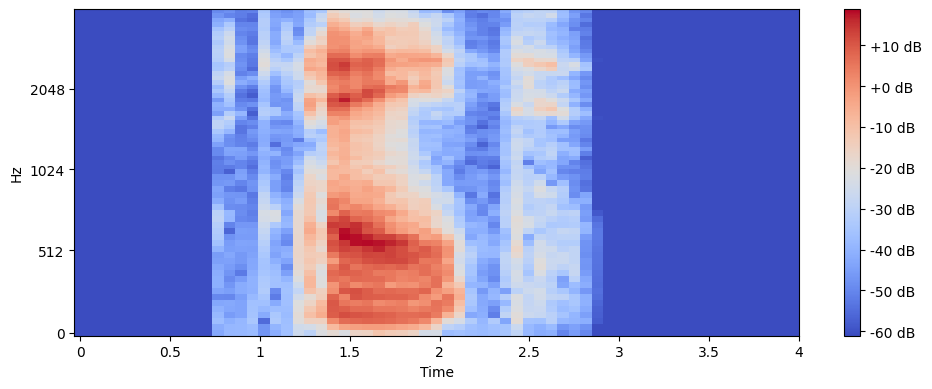

In [16]:
import librosa
import librosa.display

signal,logmel, label = dataset[0]

print("Waveform shape:", tuple(signal.shape))
print("Log-mel shape:", tuple(logmel.shape))
print(label)
# ---- Explanation
# Waveform shape [1, NUM_SAMPLES]:
#   - "1" is the mono channel.
#   - NUM_SAMPLES is the fixed number of samples (here 8000), i.e., 1 second at 8 kHz.
# Log-mel shape [n_mels, time_frames]:
#   - "n_mels" = 64 is the number of mel bands (frequency bins).
#   - "time_frames" depends on window/hop (here hop=128 @ 8kHz -> ~62.5 frames/s).

# ---- Plot log-mel with librosa.display.specshow ----
plt.figure(figsize=(10, 4))
librosa.display.specshow(logmel.squeeze(0).numpy(), sr=SAMPLE_RATE, hop_length=512, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.tight_layout()
plt.show()

### Repeat the above for the last sample in the dataset

Waveform shape: (1, 8000)
Log-mel shape: (1, 64, 63)


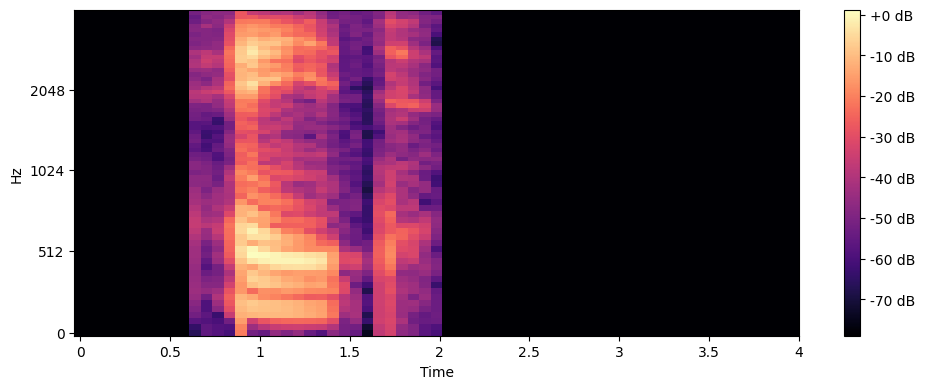

In [121]:
signal,logmel, label = dataset[-1]

print("Waveform shape:", tuple(signal.shape))
print("Log-mel shape:", tuple(logmel.shape))

plt.figure(figsize=(10, 4))
librosa.display.specshow(logmel.squeeze(0).numpy(), sr=SAMPLE_RATE, hop_length=512, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.tight_layout()
plt.show()

### Split the dataset into training (80%), validation(10%), and test (10%) dataset
##### Use the random_split from torch.utils.data

In [10]:
full_dataset = MyCustomDataset(
    audio_dir=AUDIO_DIR,
    sample_rate=SAMPLE_RATE,
    max_ms=TARGET_MS,
    transform=transform,
    device=device,
    annotation_df=annotation_df
)

from torch.utils.data import random_split

# Total number of samples
dataset_size = len(dataset)
print(f"Total samples in dataset: {dataset_size}")

# Define split sizes
train_size = int(0.8 * dataset_size)
val_size   = int(0.1 * dataset_size)
test_size  = dataset_size - train_size - val_size

train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])


print(f"Train: {len(train_ds)} samples")
print(f"Validation: {len(val_ds)} samples")
print(f"Test: {len(test_ds)} samples")


Total samples in dataset: 3000
Train: 2400 samples
Validation: 300 samples
Test: 300 samples


### Create a train, validation and test dataloaders using dataloaders from torch.utils.data
##### Use a batch size of 64
##### Remeber to turn on shuffle for training and turn it off for validation and testing

In [11]:
BATCH_SIZE = 64

# Create DataLoaders
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

## Model Classes — RNN and LSTM


### Create a RNN model class that contains the init and the forward methods
##### The model structure will be unique for every student
##### The model should consist of lstm and linear layers
##### Recall that there are 6 classes in the dataset, hence the final layer will have 6 neurons

FOR RNN:


- input_size – The number of expected features in the input x

- hidden_size – The number of features in the hidden state h

- num_layers – Number of recurrent layers. E.g., setting num_layers=2 would mean stacking two RNNs together to form a stacked RNN, with the second RNN taking in outputs of the first RNN and computing the final results. Default: 1

- nonlinearity – The non-linearity to use. Can be either 'tanh' or 'relu'. Default: 'tanh'

- bias – If False, then the layer does not use bias weights b_ih and b_hh. Default: True

- batch_first – If True, then the input and output tensors are provided as (batch, seq, feature) instead of (seq, batch, feature). Note that this does not apply to hidden or cell states. See the Inputs/Outputs sections below for details. Default: False

- dropout – If non-zero, introduces a Dropout layer on the outputs of each RNN layer except the last layer, with dropout probability equal to dropout. Default: 0

- bidirectional – If True, becomes a bidirectional RNN. Default: False

FOR LSTM:

- input_size – The number of expected features in the input x

- hidden_size – The number of features in the hidden state h

- num_layers – Number of recurrent layers. E.g., setting num_layers=2 would mean stacking two LSTMs together to form a stacked LSTM, with the second LSTM taking in outputs of the first LSTM and computing the final results. Default: 1

- bias – If False, then the layer does not use bias weights b_ih and b_hh. Default: True

- batch_first – If True, then the input and output tensors are provided as (batch, seq, feature) instead of (seq, batch, feature). Note that this does not apply to hidden or cell states. See the Inputs/Outputs sections below for details. Default: False

- dropout – If non-zero, introduces a Dropout layer on the outputs of each LSTM layer except the last layer, with dropout probability equal to dropout. Default: 0

- bidirectional – If True, becomes a bidirectional LSTM. Default: False

- proj_size – If > 0, will use LSTM with projections of corresponding size. Default: 0

In [12]:

class RNNClassifier(nn.Module):
    def __init__(self, input_size=64, hidden_size=128, num_layers=1,
                 num_classes=6, model_type='rnn', dropout=0.0, bidirectional=False):
        self.model_type = model_type
        super().__init__()
        # RNN
        if self.model_type == 'rnn':
            self.recurrent = nn.RNN(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                nonlinearity='tanh',
                batch_first=True,
                dropout=dropout,
                bidirectional=bidirectional
            )
        elif self.model_type == 'lstm':
            self.recurrent = nn.LSTM(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout,
                bidirectional=bidirectional
            )
        else:
            raise ValueError("model_type must be either 'rnn' or 'lstm'")

        # Compute output dimension (doubles if bidirectional=True)
        out_dim = hidden_size * (2 if bidirectional else 1)

        # Fully connected layer: maps hidden output → class scores
        self.fc = nn.Linear(out_dim, num_classes)

    def forward(self, x):
        # Transpose to (batch, time, n_mels) for RNN/LSTM
        x = x.transpose(1, 2)

        # Forward pass through RNN or LSTM
        if self.model_type == 'rnn':
            rnn_out, h_n = self.recurrent(x)
        else:
            rnn_out, (h_n, c_n) = self.recurrent(x)
        out = rnn_out.mean(dim=1)         # temporal mean pooling
        out = self.fc(out)
        return out


### Use the summary fuction in the torchinfo library to print the number of parameters and the estimated size of the model RNN and LSTM

### Make a comparison of the number of parameters and explain why they  are different

In [21]:
!pip install torchinfo



In [22]:
from torchinfo import summary
rnn_model = RNNClassifier(model_type='rnn', input_size=64, hidden_size=128, num_layers=1, num_classes=6)
lstm_model = RNNClassifier(model_type='lstm', input_size=64, hidden_size=128, num_layers=1, num_classes=6)

# Move models to the same device
rnn_model.to(device)
lstm_model.to(device)
summary(rnn_model,  input_size=(1, 64, 50))


Layer (type:depth-idx)                   Output Shape              Param #
RNNClassifier                            [1, 6]                    --
├─RNN: 1-1                               [1, 50, 128]              24,832
├─Linear: 1-2                            [1, 6]                    774
Total params: 25,606
Trainable params: 25,606
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.24
Input size (MB): 0.01
Forward/backward pass size (MB): 0.05
Params size (MB): 0.10
Estimated Total Size (MB): 0.17

In [126]:
summary(lstm_model, input_size=(1, 64, 50))

Layer (type:depth-idx)                   Output Shape              Param #
RNNClassifier                            [1, 6]                    --
├─LSTM: 1-1                              [1, 50, 128]              99,328
├─Linear: 1-2                            [1, 6]                    774
Total params: 100,102
Trainable params: 100,102
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 4.97
Input size (MB): 0.01
Forward/backward pass size (MB): 0.05
Params size (MB): 0.40
Estimated Total Size (MB): 0.46

LSTMs have 4 times more parameters than RNNs
because they include four gates (input, forget, cell, output)
each with its own weight matrices and biases —
giving them better control over memory, but making them heavier.

### Create a Training Function for one epoch only
##### Using a for loop, the train function will take as arguments: the model, train loader, loss function, optimizer, etc
##### Use the cross-entropy loss function and calculate accuracy

In [13]:

def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()
    total, correct, total_loss = 0, 0, 0
    loop = tqdm(loader, desc="Training", leave=False)

    for batch in loop:
        signal, spec, y = batch

        X = spec.to(device)
        y = y.long().to(device)
        if X.dim() == 4 and X.size(1) == 1:
          X = X.squeeze(1)
        #normaliaze
        X = (X - X.mean()) / X.std()

        optimizer.zero_grad()
        outputs = model(X)
        loss = loss_fn(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y).sum().item()
        total += y.size(0)

    acc = correct / total
    avg_loss = total_loss / len(loader)

    print(f"Train Accuracy: {acc:.4f} | Loss: {avg_loss:.4f}")
    return avg_loss, acc

### Run it for 1 epoch

In [36]:


model = RNNClassifier(
    model_type='rnn',
    input_size=64,
    hidden_size=128,
    num_layers=2,
    num_classes=6
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)


Training:   0%|          | 0/38 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audi

Train Accuracy: 0.5683 | Loss: 1.1881


### Create a Validation Function for one epoch only
##### Using a for loop, the validation function will take as arguments: the model, validation loader, loss function
##### It will be wise to include best model parameters are arguments at this point
##### The goal is to monitor the performance of your proposed model to avoid overfitting/underfitting, know the best epoch to save the model weights, etc.

In [14]:
def validate_one_epoch(model, val_loader, loss_fn, device):
    model.eval()
    total, correct, total_loss = 0, 0, 0
    loop = tqdm(val_loader, desc="Validation", leave=False)

    with torch.inference_mode():

        for batch in loop:
            signal, spec, y = batch

            X = spec.to(device)
            y = y.long().to(device)
            if X.dim() == 4 and X.size(1) == 1:
              X = X.squeeze(1)
            #normaliaze
            X = (X - X.mean()) / X.std()

            outputs = model(X)
            loss = loss_fn(outputs, y)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y).sum().item()
            total += y.size(0)

    acc = correct / total
    avg_loss = total_loss / len(val_loader)

    print(f"Validation Accuracy: {acc:.4f} | Loss: {avg_loss:.4f}")

    return avg_loss, acc


### VALIDATE FOR 1 EPOCH

In [134]:
best_val_loss = float("inf")
best_model_state = None

val_loss, val_acc, best_val_loss, best_model_state = validate_one_epoch(
    model, val_loader, loss_fn, best_val_loss, best_model_state, device)

print(" Training and validation complete for 1 epoch.")
print(f"Best validation loss: {best_val_loss:.4f}")

Validation Accuracy: 0.7567 | Loss: 0.7786
 New best model found — saving weights
 Training and validation complete for 1 epoch.
Best validation loss: 0.7786


### Create a Function that will call the training and validation functions just created
##### This function will interate over all the epochs that you define
##### It will also activate your early stopping, so that the model does not continue training without improvements in the validation

In [22]:
from copy import deepcopy

def full_train(
    model,
    train_loader,
    val_loader,
    loss_fn,
    optimizer,
    device,
    num_epochs=10,
    patience=5,
    min_delta=0.0
):
    best_val_loss = float('inf')
    best_model_state = None
    epochs_without_improvement = 0

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(num_epochs):
        print(f"\n Epoch {epoch + 1}/{num_epochs}")

        # Train
        avg_loss_train, acc_train = train_one_epoch(
            model, train_loader, loss_fn, optimizer, device
        )

        # Validate
        avg_loss_valid, acc_valid = validate_one_epoch(
            model, val_loader, loss_fn,
            device
        )

        # Save metrics
        train_losses.append(avg_loss_train)
        val_losses.append(avg_loss_valid)
        train_accuracies.append(acc_train)
        val_accuracies.append(acc_valid)

        # Print metrics for epoch
        print(f" Epoch {epoch+1} Summary:")
        print(f"   Train Loss: {avg_loss_train:.4f} | Train Acc: {acc_train:.4f}")
        print(f"   Val   Loss: {avg_loss_valid:.4f} | Val   Acc: {acc_valid:.4f}")

        # ---- Early stopping logic
        if avg_loss_valid < (best_val_loss - min_delta):
            print(" New best model found — saving weights")
            best_val_loss = avg_loss_valid
            best_model_state = deepcopy({k: v.detach().cpu() for k, v in model.state_dict().items()})
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            print(f"   No improvement. Patience counter: {epochs_without_improvement}/{patience}")
            if epochs_without_improvement >= patience:
                print(" Early stopping triggered.")
                break

    # ---- Restore best weights ----
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(" Restored best model weights.")

    print("\n Training complete.")
    return best_model_state, train_losses, val_losses, train_accuracies, val_accuracies

# 4) Now commence training.


### Normally, you should manually revisit the models function to tune the hyperparameters with a goal of improving the results
##### Some of the hyperparameters to be tuned include
###### Learning rate
###### Number of RNN/LSTM layers
###### Number of neurons in the fully connected layer

**HERE YOU WILL FIX THE HYPERPARAMETERS**

**IF YOU HAVE TIME: Try only to pick one hyperparameter and try 2 values different values**

### save the model weights for RNN and LSTM

In [16]:
INPUT_SIZE   = 64          # n_mels
HIDDEN_SIZE  = 128
NUM_LAYERS   = 4
BATCH_SIZE   = 32
EPOCHS       = 10
PATIENCE     = 3
LEARNING_RATE = 1e-3
NUM_CLASSES=6
DROPOUT=0.2

In [40]:

# RNN model
rnn_model = RNNClassifier(
    model_type='rnn',
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
).to(device)

# LSTM model
lstm_model = RNNClassifier(
    model_type='lstm',
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
).to(device)

loss_fn = nn.CrossEntropyLoss()
opt_rnn  = optim.Adam(rnn_model.parameters(),  lr=LEARNING_RATE)
opt_lstm = optim.Adam(lstm_model.parameters(), lr=LEARNING_RATE)


In [23]:
best_rnn_model, rnn_train_losses, rnn_val_losses, rnn_train_accs, rnn_val_accs = full_train(
    rnn_model, train_loader, val_loader,
    loss_fn, opt_rnn, device,
    num_epochs=EPOCHS, patience=PATIENCE
)

torch.save(best_rnn_model, '/content/drive/MyDrive/FSDD/best_rnn_weights.pth')

print("Saved: best_rnn_weights.pth")


 Epoch 1/10


Train Accuracy: 0.8508 | Loss: 0.4482


Validation Accuracy: 0.8400 | Loss: 0.4644
 Epoch 1 Summary:
   Train Loss: 0.4482 | Train Acc: 0.8508
   Val   Loss: 0.4644 | Val   Acc: 0.8400
 New best model found — saving weights

 Epoch 2/10


Train Accuracy: 0.8779 | Loss: 0.3463


Validation Accuracy: 0.9100 | Loss: 0.2943
 Epoch 2 Summary:
   Train Loss: 0.3463 | Train Acc: 0.8779
   Val   Loss: 0.2943 | Val   Acc: 0.9100
 New best model found — saving weights

 Epoch 3/10


...

Validation Accuracy: 0.9533 | Loss: 0.1069
 Epoch 8 Summary:
   Train Loss: 0.1457 | Train Acc: 0.9500
   Val   Loss: 0.1069 | Val   Acc: 0.9533
 New best model found — saving weights

 Epoch 9/10


Train Accuracy: 0.9758 | Loss: 0.0858


Validation Accuracy: 0.9767 | Loss: 0.1024
 Epoch 9 Summary:
   Train Loss: 0.0858 | Train Acc: 0.9758
   Val   Loss: 0.1024 | Val   Acc: 0.9767
 New best model found — saving weights

 Epoch 10/10


Train Accuracy: 0.9838 | Loss: 0.0767


Validation Accuracy: 0.9700 | Loss: 0.0632
 Epoch 10 Summary:
   Train Loss: 0.0767 | Train Acc: 0.9838
   Val   Loss: 0.0632 | Val   Acc: 0.9700
 New best model found — saving weights
 Restored best model weights.

 Training complete.
Saved: best_rnn_weights.pth


In [24]:
# --- LSTM ---
best_lstm_model, lstm_train_losses, lstm_val_losses, lstm_train_accs, lstm_val_accs = full_train(
    lstm_model, train_loader, val_loader,
    loss_fn, opt_lstm, device,
    num_epochs=EPOCHS, patience=PATIENCE
)

torch.save(best_lstm_model, '/content/drive/MyDrive/FSDD/best_lstm_weights.pth')
print(" Saved: best_lstm_weights.pth")


 Epoch 1/10


Train Accuracy: 0.3683 | Loss: 1.5067


Validation Accuracy: 0.5700 | Loss: 1.1260
 Epoch 1 Summary:
   Train Loss: 1.5067 | Train Acc: 0.3683
   Val   Loss: 1.1260 | Val   Acc: 0.5700
 New best model found — saving weights

 Epoch 2/10


Train Accuracy: 0.5467 | Loss: 0.9733


Validation Accuracy: 0.5700 | Loss: 0.7954
 Epoch 2 Summary:
   Train Loss: 0.9733 | Train Acc: 0.5467
   Val   Loss: 0.7954 | Val   Acc: 0.5700
 New best model found — saving weights

 Epoch 3/10


...

Validation Accuracy: 0.9733 | Loss: 0.1212
 Epoch 8 Summary:
   Train Loss: 0.1776 | Train Acc: 0.9396
   Val   Loss: 0.1212 | Val   Acc: 0.9733
 New best model found — saving weights

 Epoch 9/10


Train Accuracy: 0.9650 | Loss: 0.1141


Validation Accuracy: 0.9967 | Loss: 0.0585
 Epoch 9 Summary:
   Train Loss: 0.1141 | Train Acc: 0.9650
   Val   Loss: 0.0585 | Val   Acc: 0.9967
 New best model found — saving weights

 Epoch 10/10


Train Accuracy: 0.9725 | Loss: 0.0851


Validation Accuracy: 0.9933 | Loss: 0.0459
 Epoch 10 Summary:
   Train Loss: 0.0851 | Train Acc: 0.9725
   Val   Loss: 0.0459 | Val   Acc: 0.9933
 New best model found — saving weights
 Restored best model weights.

 Training complete.
 Saved: best_lstm_weights.pth


### Make a plot of the training and validation losses as well as the accuracies over all the epochs considered

In [25]:
def plot_training_curves(train_losses, val_losses, train_accs, val_accs):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Losses
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracies
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, label='Train Accuracy')
    plt.plot(epochs, val_accs, label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

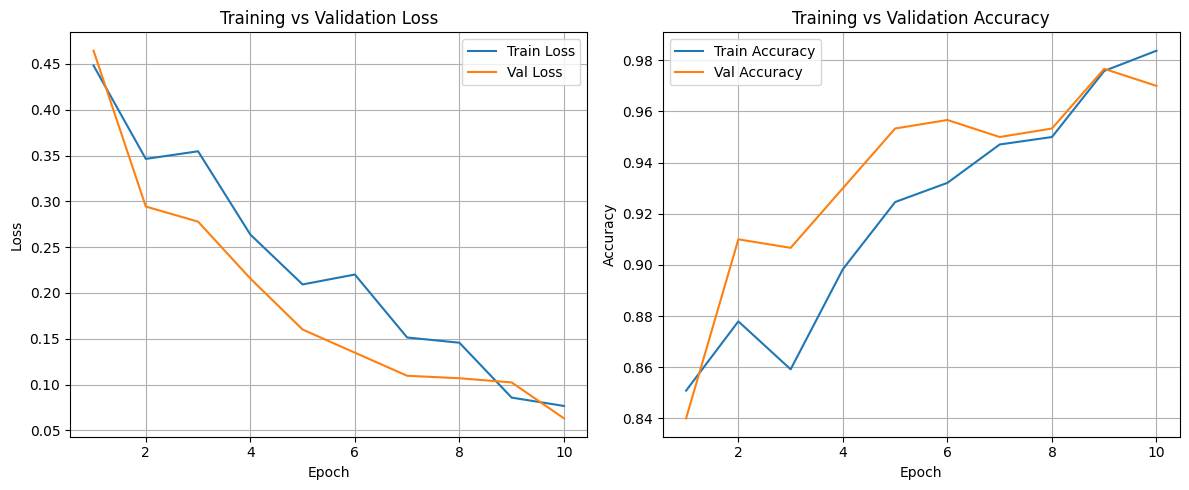

In [26]:

# Load the best model weights
rnn_model.load_state_dict(torch.load('/content/drive/MyDrive/FSDD/best_rnn_weights.pth'))
rnn_model.eval()  # set to evaluation model
plot_training_curves(rnn_train_losses, rnn_val_losses, rnn_train_accs, rnn_val_accs)

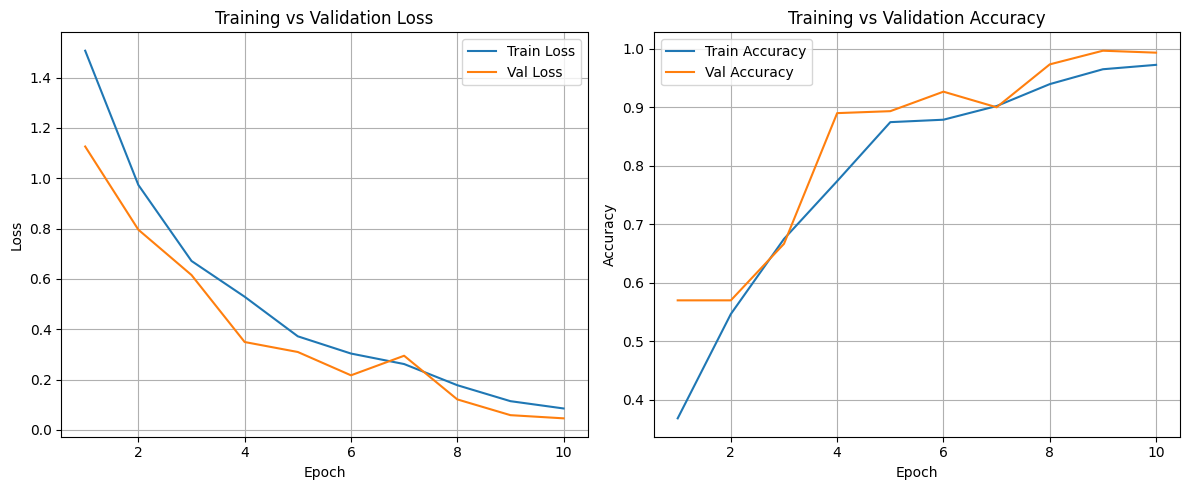

In [42]:
# Load the best model weights
lstm_model.load_state_dict(torch.load('/content/drive/MyDrive/FSDD/best_lstm_weights.pth'))
lstm_model.eval()  # set to evaluation model
plot_training_curves(lstm_train_losses, lstm_val_losses, lstm_train_accs, lstm_val_accs)

#TEST

### Create a Test function
##### This will use the best models weights over the test data
##### The performance on the test data should be similar to the performance recorded at the best epoch during training and validation

In [34]:
def test_one_epoch(model, val_loader, loss_fn, device):
    model.eval()
    total, correct, total_loss = 0, 0, 0
    loop = tqdm(val_loader, desc="Testing", leave=False)

    pred_tot=[]
    true_tot=[]
    for batch in loop:
        signal, spec, y = batch

        X = spec.to(device)
        y = y.long().to(device)
        if X.dim() == 4 and X.size(1) == 1:
          X = X.squeeze(1)
        #normaliaze
        X = (X - X.mean()) / X.std()

        outputs = model(X)
        loss = loss_fn(outputs, y)

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y).sum().item()
        total += y.size(0)
        pred_tot.extend(predicted.cpu().numpy())
        true_tot.extend(y.cpu().numpy())


    acc = correct / total
    avg_loss = total_loss / len(val_loader)

    print(f"Testing Accuracy: {acc:.4f} | Loss: {avg_loss:.4f}")

    return avg_loss, acc,pred_tot,true_tot

In [35]:
rnn_model.load_state_dict(torch.load('/content/drive/MyDrive/FSDD/best_rnn_weights.pth'))
rnn_model.eval()
rnn_test_loss, rnn_test_acc,rnn_pred,rnn_true = test_one_epoch(rnn_model, test_loader, loss_fn, device)

Testing:   0%|          | 0/5 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/

Testing Accuracy: 0.9867 | Loss: 0.0462


In [44]:
lstm_model.load_state_dict(torch.load('/content/drive/MyDrive/FSDD/best_lstm_weights.pth'))
lstm_model.eval()
test_loss, test_acc,lstm_pred,lstm_true = test_one_epoch(lstm_model, test_loader, loss_fn, device)

Testing:   0%|          | 0/5 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/

Testing Accuracy: 0.9800 | Loss: 0.0706


### Evaluate the performance using Confusion Matrix and Classification Report
##### The sklearn library provides functions that can be used to visualize these results


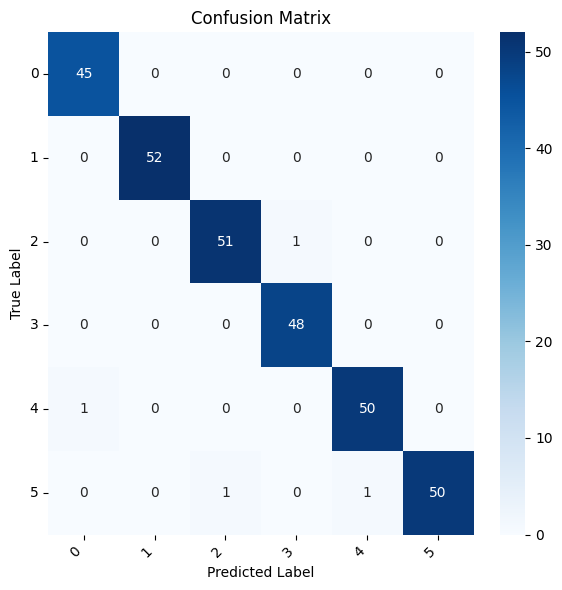

In [38]:
import seaborn as sns


# Confusion Matrix
cm = confusion_matrix(rnn_true,rnn_pred)

# Plot it
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

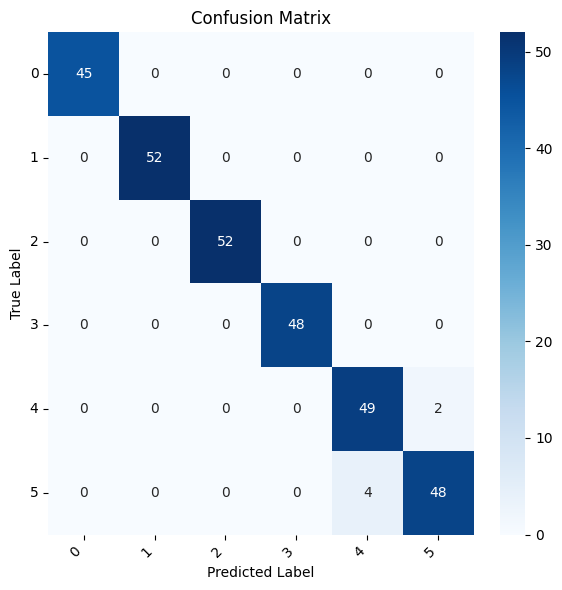

In [45]:
# Confusion Matrix
cm = confusion_matrix(lstm_true,lstm_pred)

# Plot it
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()